# Heteroscedastic mixed-variable BO — 3-method comparison

| study | model of the 5 categories | shares? |
|---|---|---|
| `study_v2` (LVGP) | one latent-variable GP | yes |
| `study_v2_gp` | 5 independent GPs | **no** |
| `study_v2_cat` (Method C) | one MixedSingleTaskGP + CategoricalKernel | yes |

**Kernel: ml_gp_env.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys; sys.path.insert(0, os.path.abspath("study_v2_cat"))
%matplotlib inline
import numpy as np, pandas as pd
from utils import StudyResults, compare_studies, compare_studies_multi, problem
from utils.results import _metric_trajectories, _cfg_param
lvgp = StudyResults.load("study_v2/results"); gp = StudyResults.load("study_v2_gp/results")
cat  = StudyResults.load("study_v2_cat/results")
studies = [(lvgp, "LVGP"), (gp, "Per-category GP"), (cat, "Categorical GP")]
print({lab: len(s.runs) for s, lab in studies}, "runs | f* =", round(problem.ground_truth_min(),4))

{'LVGP': 1080, 'Per-category GP': 1080, 'Categorical GP': 1080} runs | f* = 0.4651


## Two booleans control the comparison plots
- **`is_ground_truth`** — how a sampled point is scored: `True` = noiseless `f_true` (best ≥ f\*),
  `False` = noisy sample-mean (best can be < f\*).
- **`as_regret`** — what to plot: `True` = the **difference** value − f\* (regret; log axis when
  noiseless), `False` = the **raw best value** (converges to f\* ≈ 0.465; linear, with an f\* line).

### Final TRUE value of the best evaluated design (≥ f\*)

In [2]:
def final_true_value_table(studies, n_rep=10):
    cols = {}
    for s, lab in studies:
        t = _metric_trajectories(s, "true", n_rep, as_regret=False)     # raw best true VALUE
        cols[lab] = {problem.label(c[0], _cfg_param(c)): v[1][-1] for c, v in t.items()}
    order = [problem.label(a, p) for a, p in problem.CONFIG_ORDER]
    return pd.DataFrame(cols).reindex([o for o in order if o in pd.DataFrame(cols).index])
print(f"f* = {problem.ground_truth_min():.4f}")
final_true_value_table(studies, n_rep=10).round(4)

f* = 0.4651


,LVGP,Per-category GP,Categorical GP
LCB,0.5532,0.4824,0.5753
PI,1.5105,1.0282,0.6123
EI,0.5025,2.4193,0.5862
HAEI(γ=0.5),0.4678,0.5623,0.5664
HAEI(γ=1),0.4698,0.4822,0.5338
HAEI(γ=5),0.4739,0.4709,0.5113
ANPEI(β=0.2),1.2978,1.6305,1.5548
ANPEI(β=0.5),0.5193,2.2771,0.5159
ANPEI(β=0.8),0.4660,2.1074,0.5300
RAHBO(α=0.5),0.4672,0.4727,0.4962


## Noiseless — REGRET view (difference, log axis): `is_ground_truth=True, as_regret=True`

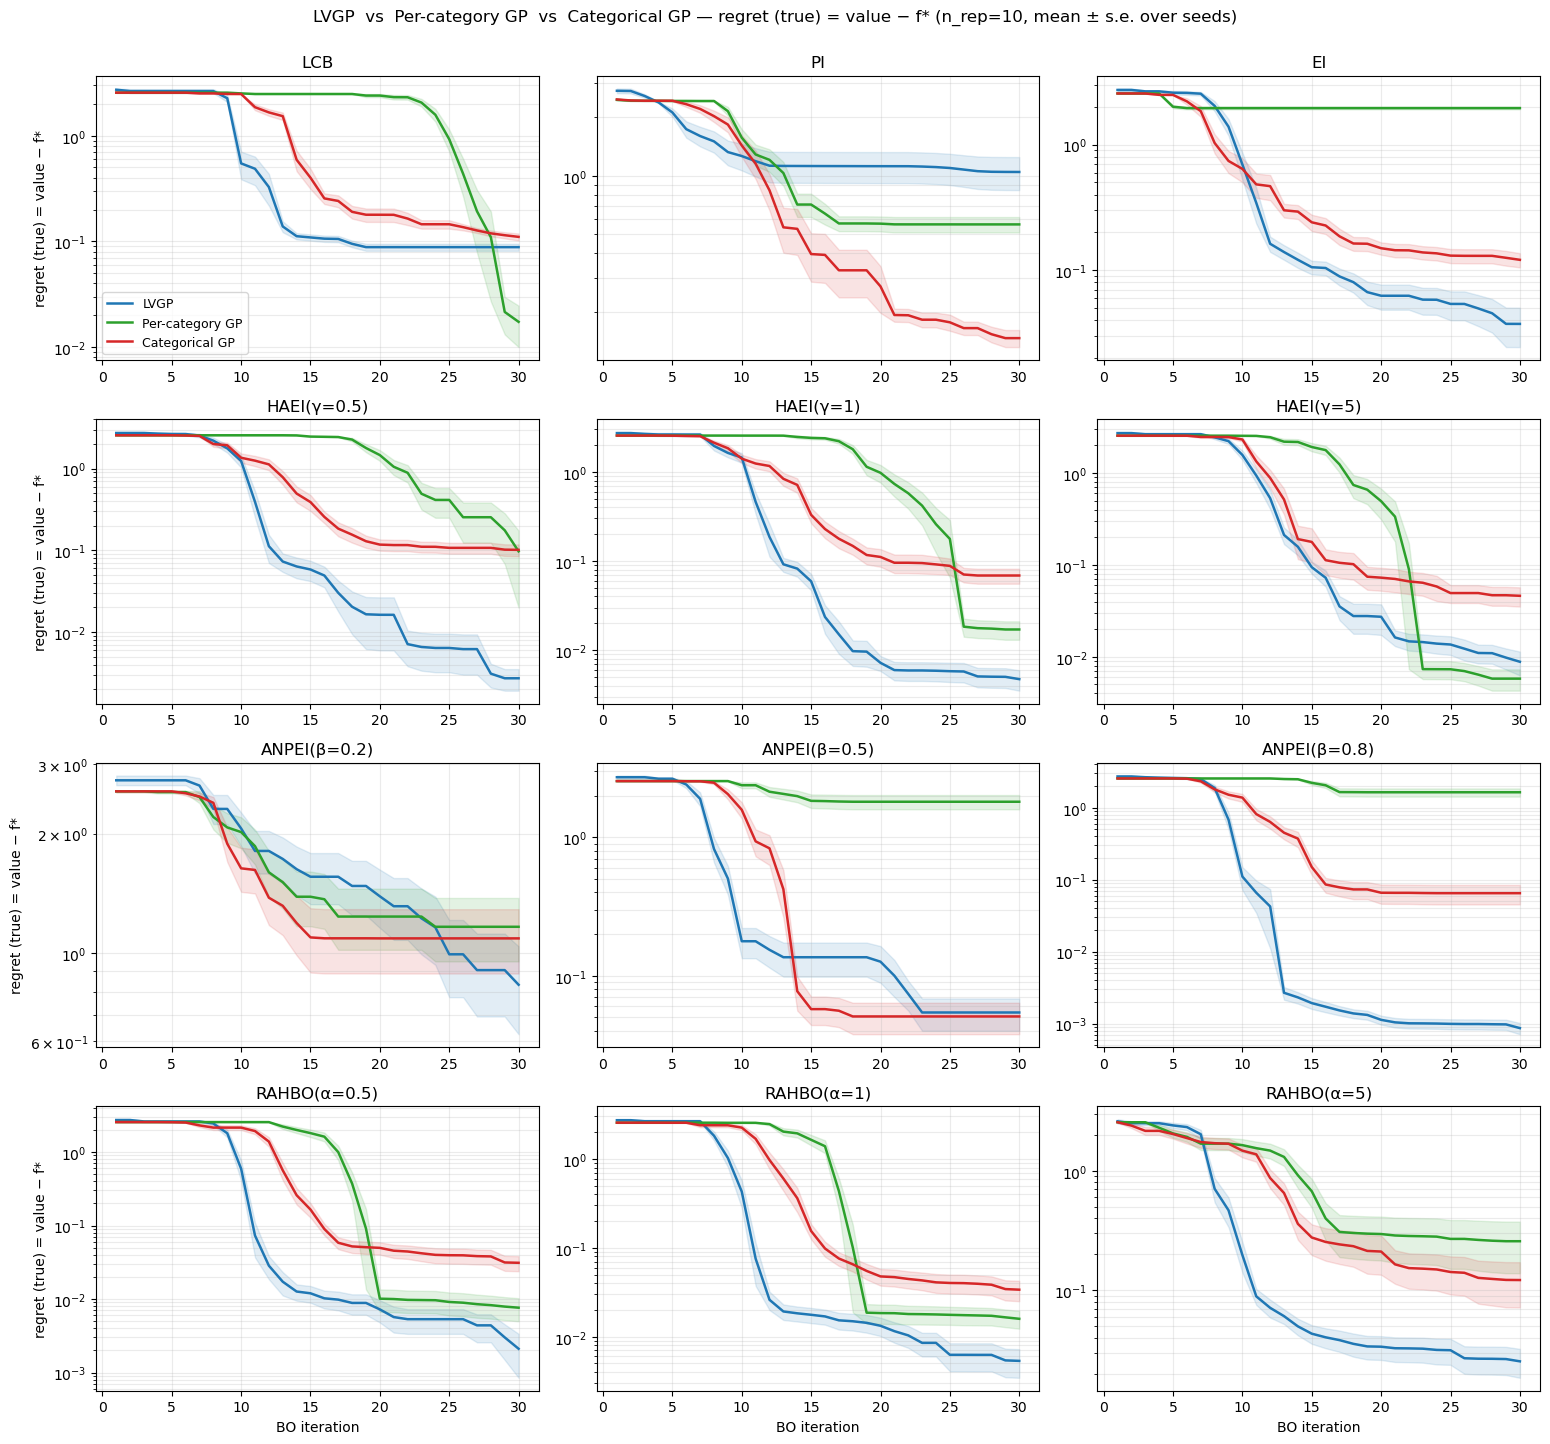

In [3]:
compare_studies_multi(studies, is_ground_truth=True, as_regret=True, n_rep=10)

## Noiseless — VALUE view (converges to f\* ≈ 0.465, linear): `as_regret=False`

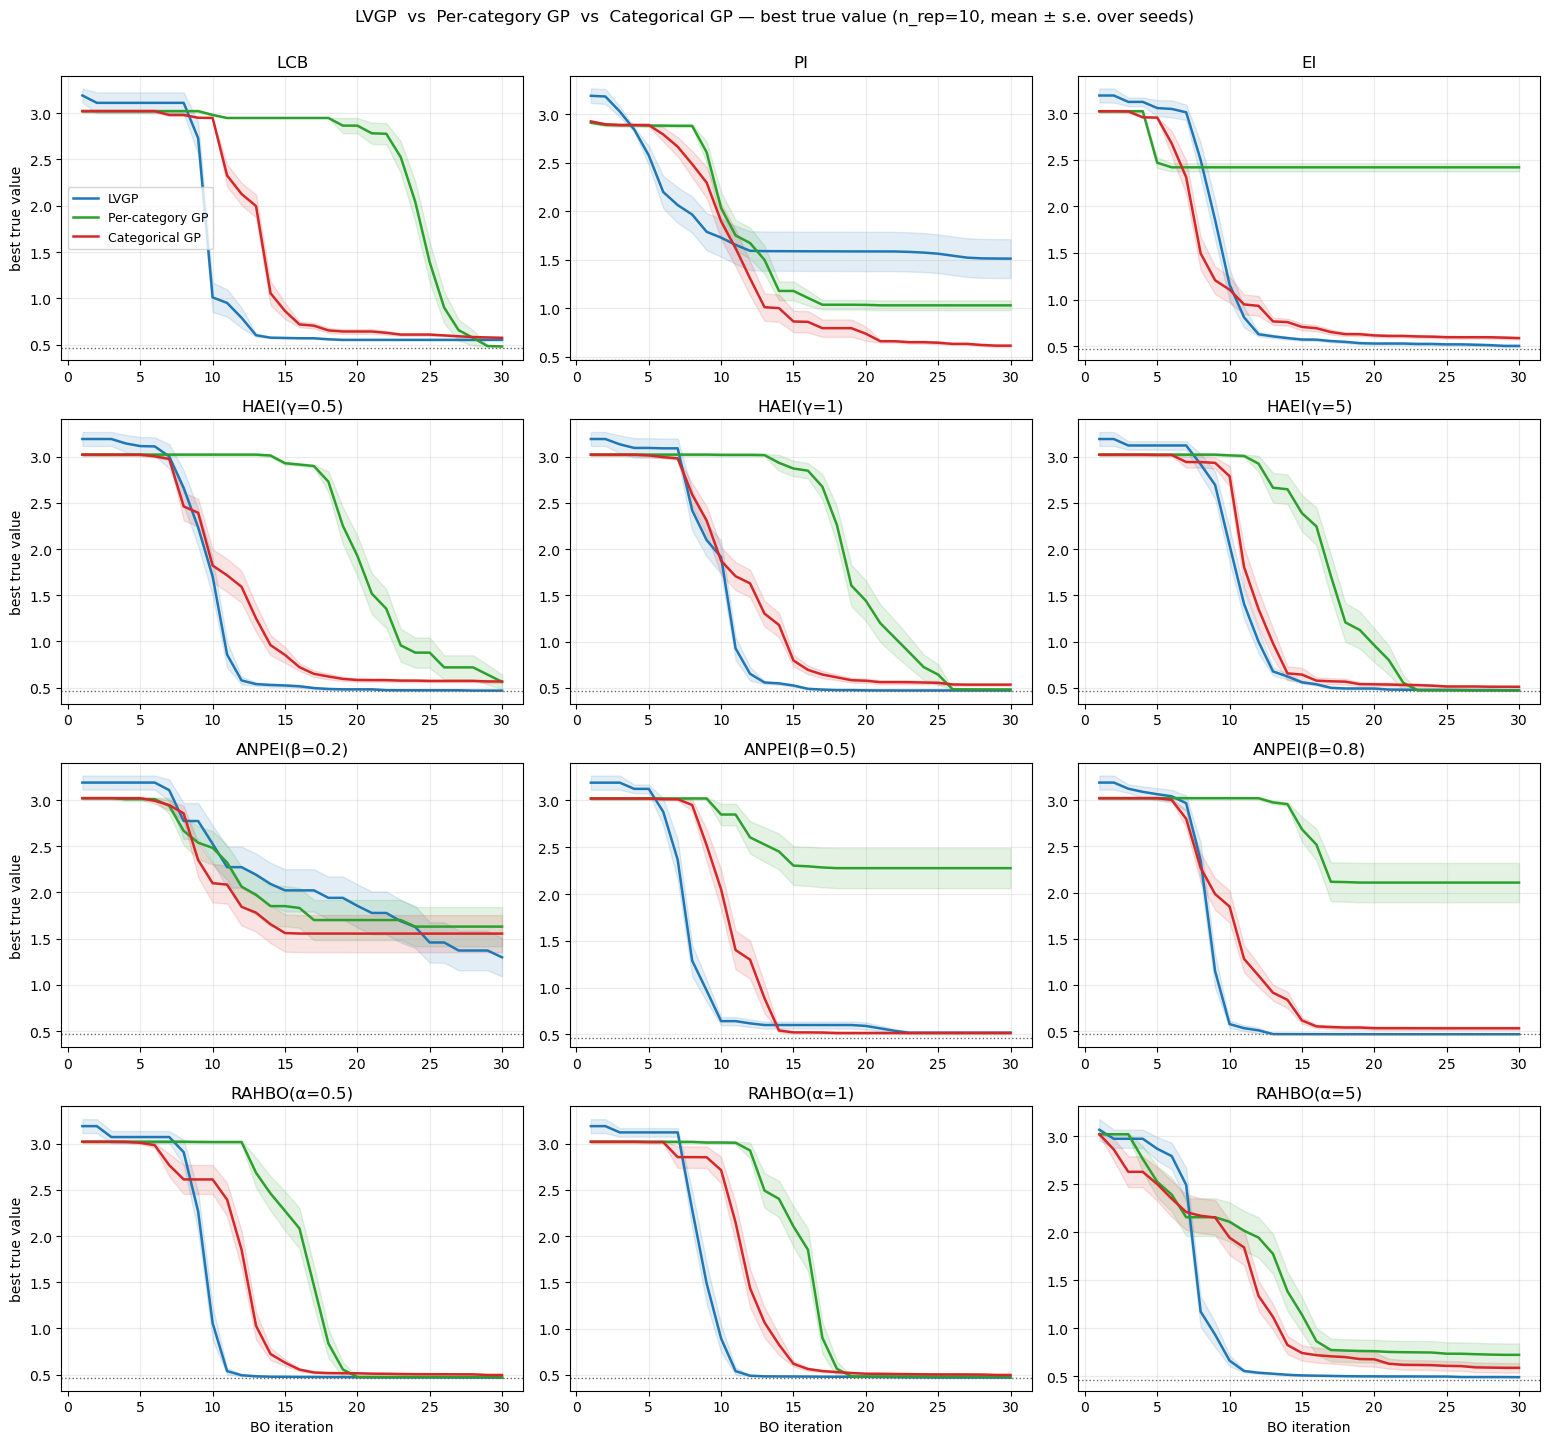

In [4]:
compare_studies_multi(studies, is_ground_truth=True, as_regret=False, n_rep=10)

## Noisy — for contrast (`is_ground_truth=False`; can dip below f\*)

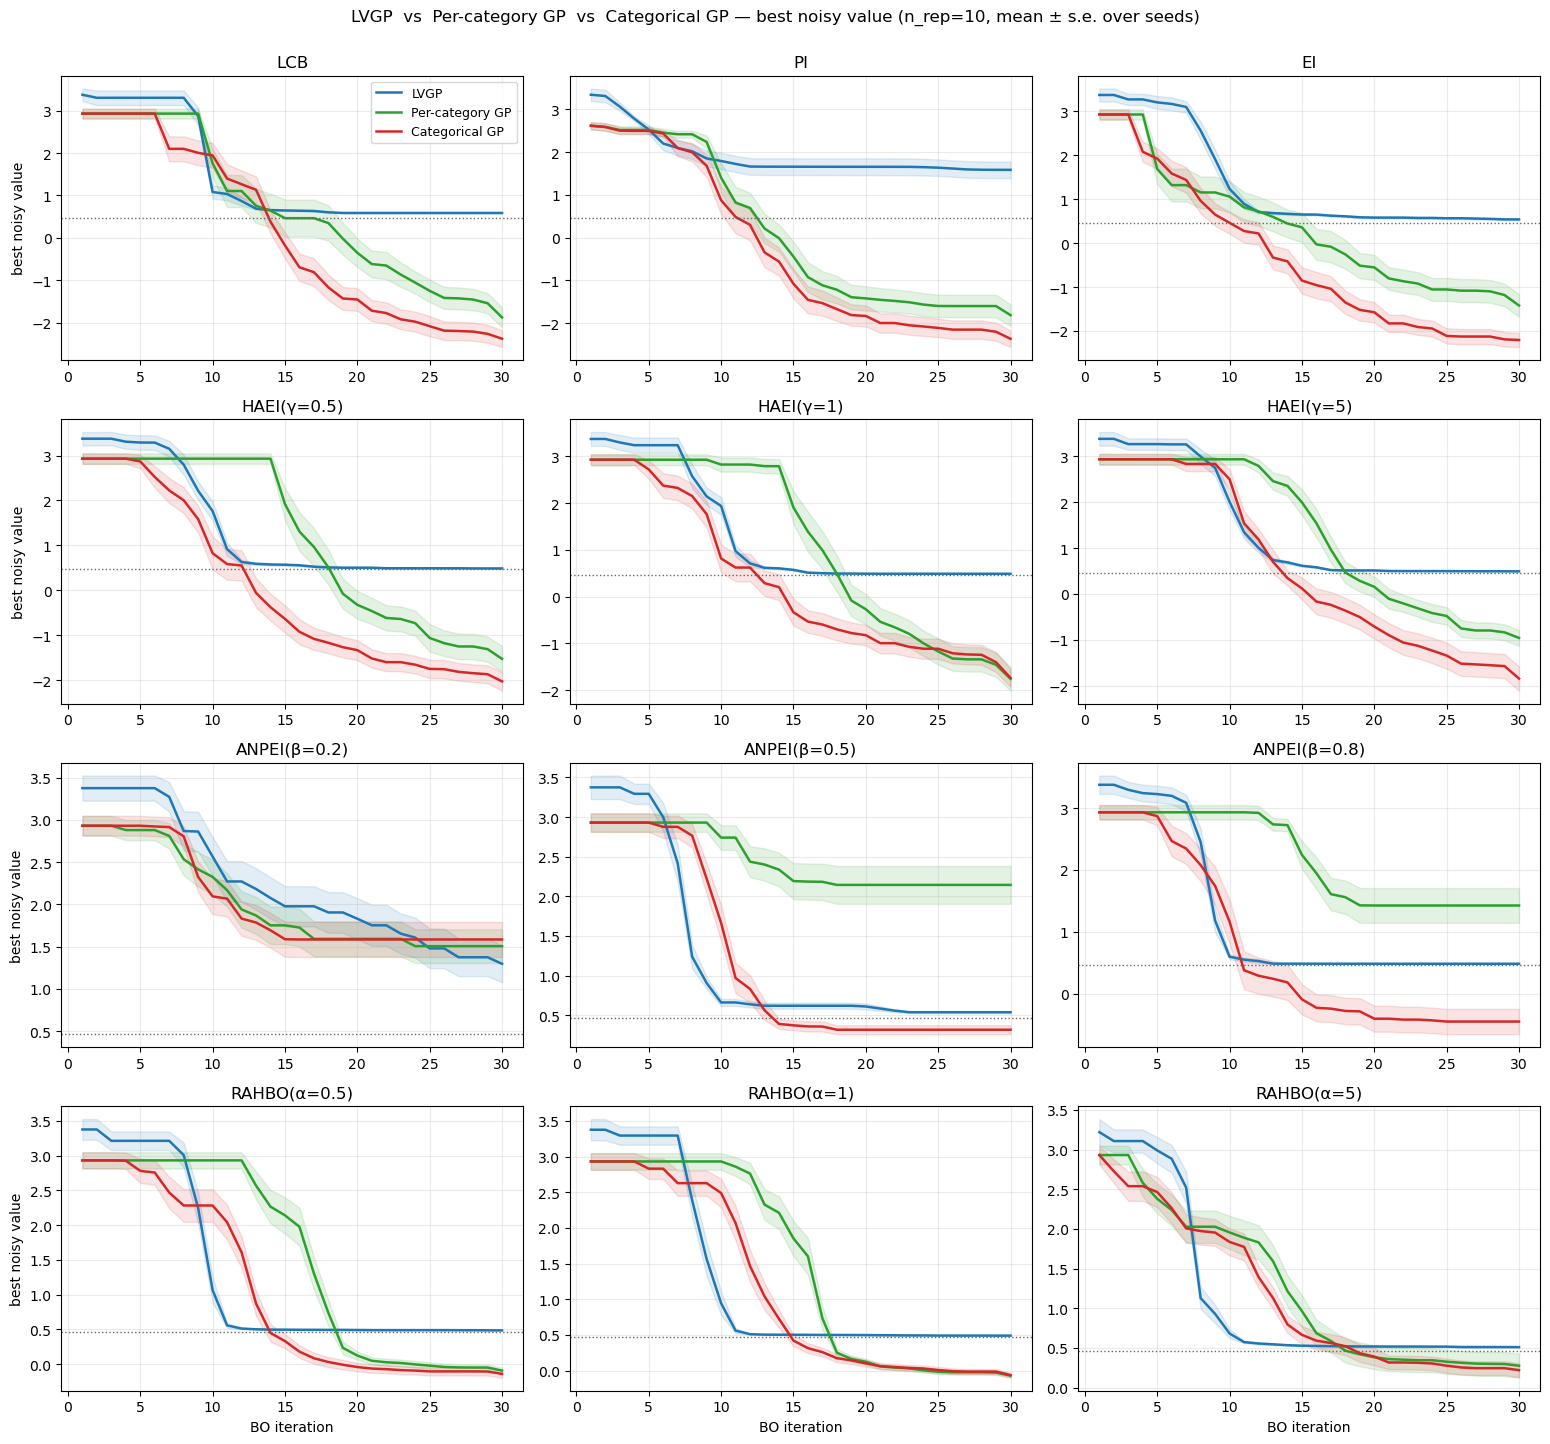

In [5]:
compare_studies_multi(studies, is_ground_truth=False, as_regret=False, n_rep=10)

## Pairwise (categorical GP vs each), noiseless value view

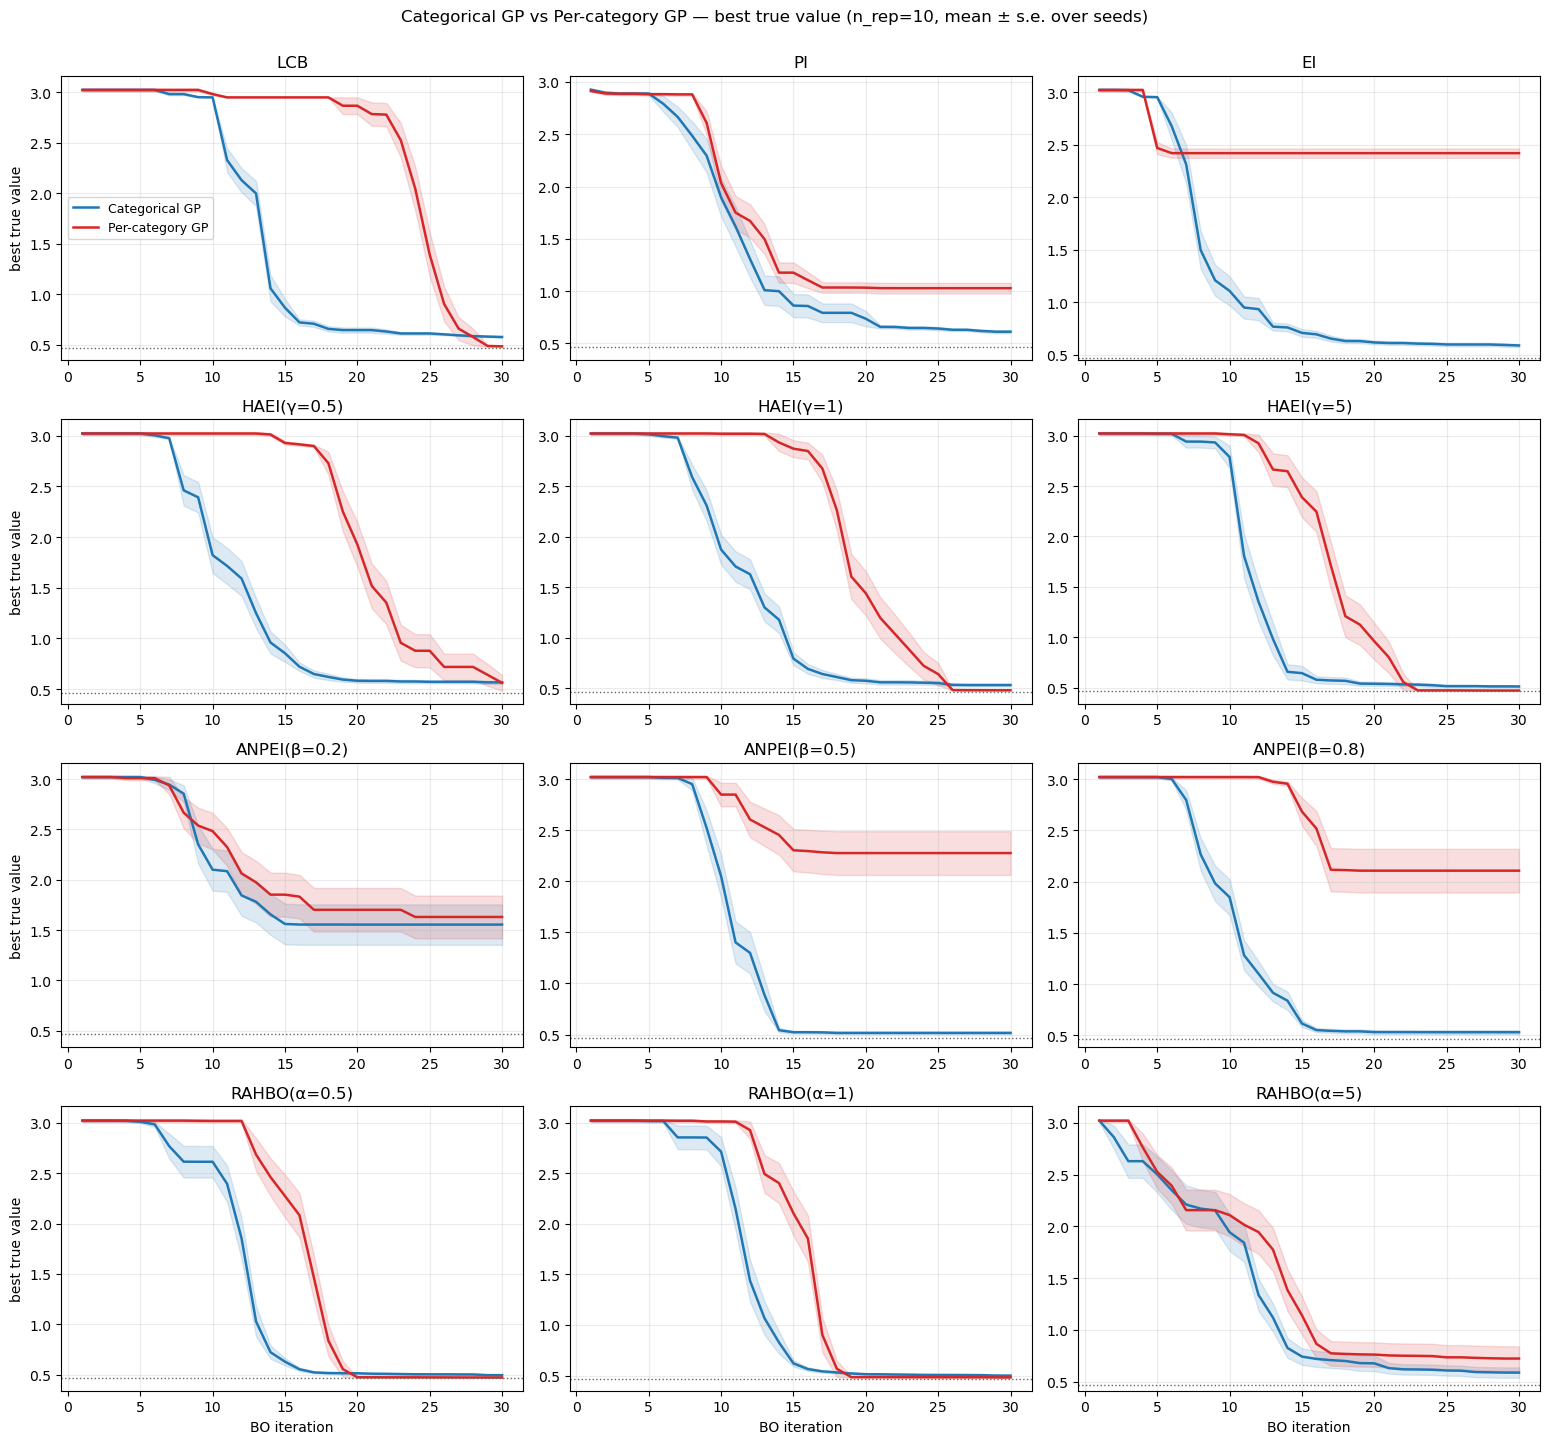

In [6]:
compare_studies(cat, gp,   is_ground_truth=True, as_regret=False, n_rep=10, labels=("Categorical GP", "Per-category GP"))

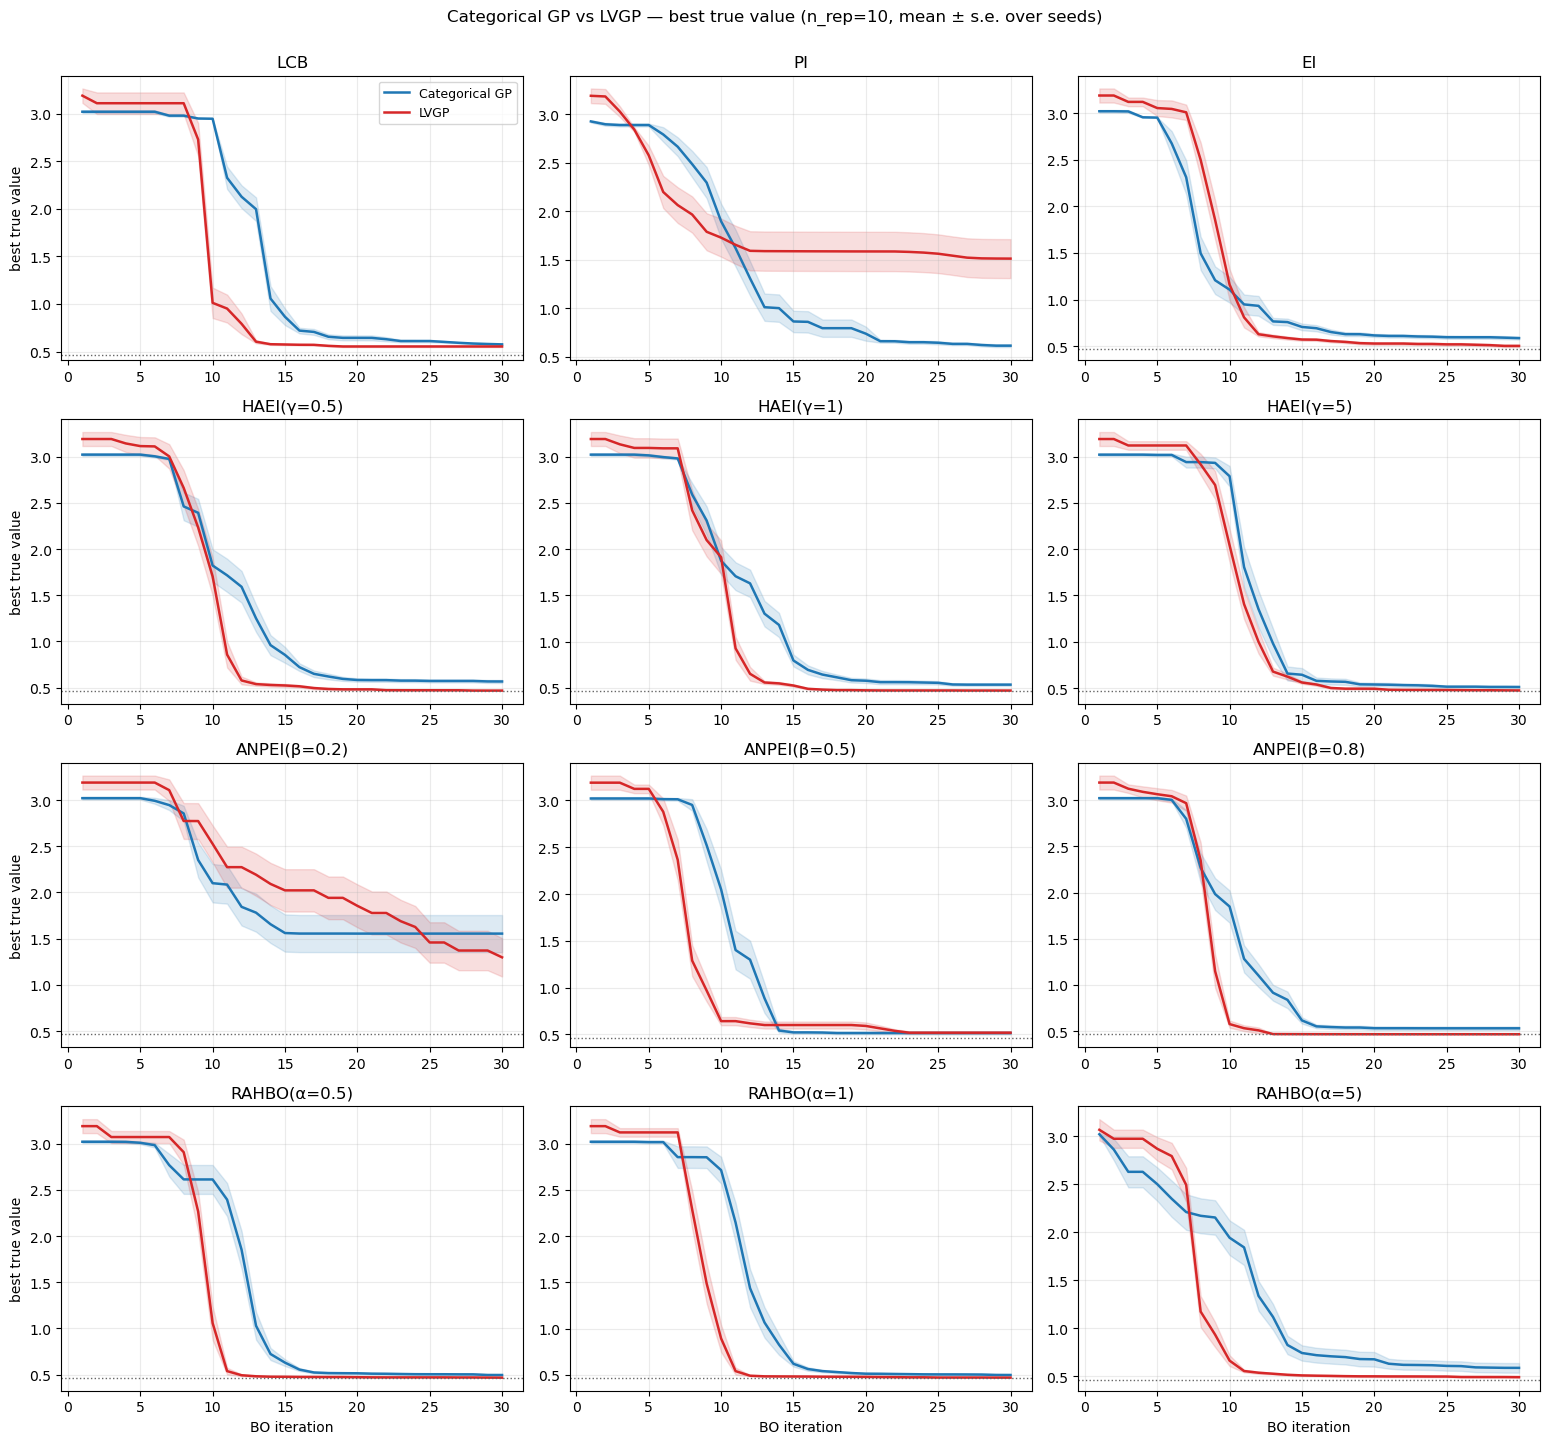

In [7]:
compare_studies(cat, lvgp, is_ground_truth=True, as_regret=False, n_rep=10, labels=("Categorical GP", "LVGP"))